# 🚀 GPT

In this notebook, we'll walk through the steps required to train your own GPT model on the wine review dataset

The code is adapted from the excellent [GPT tutorial](https://keras.io/examples/generative/text_generation_with_miniature_gpt/) created by Apoorv Nandan available on the Keras website.

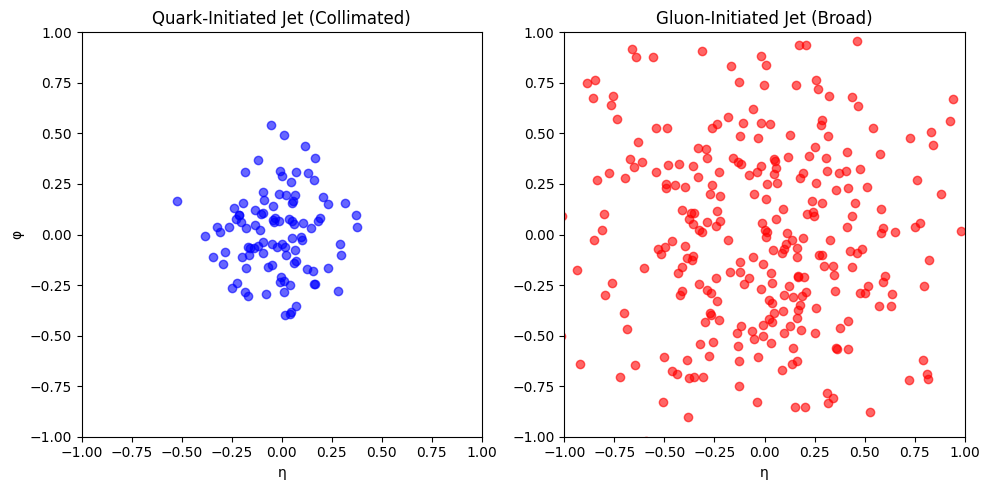

In [ ]:
# Difference in jet initiated from quark or gluon

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic jet profile data
np.random.seed(42)

# Quark jet: More collimated
quark_jet_radii = np.random.normal(loc=0, scale=0.2, size=(100, 2))

# Gluon jet: Wider spread
gluon_jet_radii = np.random.normal(loc=0, scale=0.5, size=(300, 2))

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Quark-initiated jet
axes[0].scatter(quark_jet_radii[:, 0], quark_jet_radii[:, 1], color='blue', alpha=0.6, label="Particles")
axes[0].set_title("Quark-Initiated Jet (Collimated)")
axes[0].set_xlim(-1, 1)
axes[0].set_ylim(-1, 1)
axes[0].set_xlabel("η")
axes[0].set_ylabel("φ")

# Gluon-initiated jet
axes[1].scatter(gluon_jet_radii[:, 0], gluon_jet_radii[:, 1], color='red', alpha=0.6, label="Particles")
axes[1].set_title("Gluon-Initiated Jet (Broad)")
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(-1, 1)
axes[1].set_xlabel("η")

plt.tight_layout()
plt.show()


In [2]:
#%load_ext autoreload
#%autoreload 2
import numpy as np
import json
import re
import string
from IPython.display import display, HTML

import tensorflow as tf
from tensorflow.keras import layers, models, losses, callbacks

## 0. Parameters <a name="parameters"></a>

In [3]:
VOCAB_SIZE = 10000
MAX_LEN = 80
EMBEDDING_DIM = 256
KEY_DIM = 256
N_HEADS = 2
FEED_FORWARD_DIM = 256
VALIDATION_SPLIT = 0.2
SEED = 42
LOAD_MODEL = False
BATCH_SIZE = 32
EPOCHS = 5

## 1. Load the data <a name="load"></a>

In [4]:
# Load the full dataset
with open("./wine-reviews/winemag-data-130k-v2.json") as json_data:
    wine_data = json.load(json_data)

In [5]:
wine_data[10]

{'points': '87',
 'title': 'Kirkland Signature 2011 Mountain Cuvée Cabernet Sauvignon (Napa Valley)',
 'description': 'Soft, supple plum envelopes an oaky structure in this Cabernet, supported by 15% Merlot. Coffee and chocolate complete the picture, finishing strong at the end, resulting in a value-priced wine of attractive flavor and immediate accessibility.',
 'taster_name': 'Virginie Boone',
 'taster_twitter_handle': '@vboone',
 'price': 19,
 'designation': 'Mountain Cuvée',
 'variety': 'Cabernet Sauvignon',
 'region_1': 'Napa Valley',
 'region_2': 'Napa',
 'province': 'California',
 'country': 'US',
 'winery': 'Kirkland Signature'}

In [6]:
# Filter the dataset
filtered_data = [
    "wine review : "
    + x["country"]
    + " : "
    + x["province"]
    + " : "
    + x["variety"]
    + " : "
    + x["description"]
    for x in wine_data
    if x["country"] is not None
    and x["province"] is not None
    and x["variety"] is not None
    and x["description"] is not None
]

In [7]:
# Count the recipes
n_wines = len(filtered_data)
print(f"{n_wines} recipes loaded")

129907 recipes loaded


In [8]:
example = filtered_data[25]
print(example)

wine review : US : California : Pinot Noir : Oak and earth intermingle around robust aromas of wet forest floor in this vineyard-designated Pinot that hails from a high-elevation site. Small in production, it offers intense, full-bodied raspberry and blackberry steeped in smoky spice and smooth texture.


## 2. Tokenize the data <a name="tokenize"></a>

In [9]:
# Pad the punctuation, to treat them as separate 'words'
def pad_punctuation(s):
    s = re.sub(f"([{string.punctuation}, '\n'])", r" \1 ", s)
    s = re.sub(" +", " ", s)
    return s


text_data = [pad_punctuation(x) for x in filtered_data]

In [10]:
# Display an example of a recipe
example_data = text_data[25]
example_data

'wine review : US : California : Pinot Noir : Oak and earth intermingle around robust aromas of wet forest floor in this vineyard - designated Pinot that hails from a high - elevation site . Small in production , it offers intense , full - bodied raspberry and blackberry steeped in smoky spice and smooth texture . '

In [11]:
# Convert to a Tensorflow Dataset
text_ds = (
    tf.data.Dataset.from_tensor_slices(text_data)
    .batch(BATCH_SIZE)
    .shuffle(1000)
)

In [12]:
# Create a vectorization layer to process text data
vectorize_layer = layers.TextVectorization(
    standardize="lower",  # Converts text to lowercase to maintain consistency
    max_tokens=VOCAB_SIZE,  # Limits the vocabulary size to VOCAB_SIZE most frequent words
    output_mode="int",  # Converts tokens (words) into integer indices
    output_sequence_length=MAX_LEN + 1,  # Pads or truncates sequences to a fixed length
)


In [13]:
# Adapt the layer to the training set
vectorize_layer.adapt(text_ds)
vocab = vectorize_layer.get_vocabulary()

In [14]:
# Display some token:word mappings
for i, word in enumerate(vocab[:11]):
    print(f"{i}: {word}")

0: 
1: [UNK]
2: :
3: ,
4: .
5: and
6: the
7: wine
8: a
9: of
10: review


In [15]:
# Display the same example converted to ints
example_tokenised = vectorize_layer(example_data)
print(example_data)
print(example_tokenised.numpy())

wine review : US : California : Pinot Noir : Oak and earth intermingle around robust aromas of wet forest floor in this vineyard - designated Pinot that hails from a high - elevation site . Small in production , it offers intense , full - bodied raspberry and blackberry steeped in smoky spice and smooth texture . 
[   7   10    2   20    2   29    2   43   62    2   55    5  243 4145
  453  634   26    9  497  499  667   17   12  142   14 2214   43   25
 2484   32    8  223   14 2213  948    4  594   17  987    3   15   75
  237    3   64   14   82   97    5   74 2633   17  198   49    5  125
   77    4    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0]


## 3. Create the Training Set <a name="create"></a>

In [16]:
# Create the training set of reviews and the same text shifted by one word
def prepare_inputs(text):
    text = tf.expand_dims(text, -1)  # Expands dimensions to match vectorization layer input format
    tokenized_sentences = vectorize_layer(text)  # Convert text into tokenized sequences (integer representation)
    x = tokenized_sentences[:, :-1]  # Input sequence (all words except last). First argument is batch 
    y = tokenized_sentences[:, 1:]   # Target sequence (all words except first, i.e., shifted by one)
    return x, y

train_ds = text_ds.map(prepare_inputs)

In [17]:
example_input_output = train_ds.take(1).get_single_element()

In [18]:
example_input_output

(<tf.Tensor: shape=(32, 80), dtype=int64, numpy=
 array([[ 7, 10,  2, ...,  0,  0,  0],
        [ 7, 10,  2, ...,  0,  0,  0],
        [ 7, 10,  2, ...,  0,  0,  0],
        ...,
        [ 7, 10,  2, ...,  0,  0,  0],
        [ 7, 10,  2, ...,  0,  0,  0],
        [ 7, 10,  2, ...,  0,  0,  0]])>,
 <tf.Tensor: shape=(32, 80), dtype=int64, numpy=
 array([[ 10,   2,  40, ...,   0,   0,   0],
        [ 10,   2,  40, ...,   0,   0,   0],
        [ 10,   2, 397, ...,   0,   0,   0],
        ...,
        [ 10,   2,  20, ...,   0,   0,   0],
        [ 10,   2,  20, ...,   0,   0,   0],
        [ 10,   2,  40, ...,   0,   0,   0]])>)

In [19]:
# Example Input
example_input_output[0][0]

<tf.Tensor: shape=(80,), dtype=int64, numpy=
array([   7,   10,    2,   40,    2,  321,    2,  883,    3,  955,    3,
        981,    2,  416, 3596,    3,   12,   13,    8,  218,    3,  346,
          7,   25, 1231,    6,   28,  111,    8, 2858,    9, 8882,    4,
         26,  944, 1350,  937,    3,  659,  444,    3, 1387,    3,   78,
         22,    5,   67,    3,   49,    5,  171,    4,  112,  949,    3,
         15,  211, 1010,    9, 1228, 6598,   51,   71,    4,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0])>

In [20]:
# Example Output (shifted by one token)
example_input_output[1][0]

<tf.Tensor: shape=(80,), dtype=int64, numpy=
array([  10,    2,   40,    2,  321,    2,  883,    3,  955,    3,  981,
          2,  416, 3596,    3,   12,   13,    8,  218,    3,  346,    7,
         25, 1231,    6,   28,  111,    8, 2858,    9, 8882,    4,   26,
        944, 1350,  937,    3,  659,  444,    3, 1387,    3,   78,   22,
          5,   67,    3,   49,    5,  171,    4,  112,  949,    3,   15,
        211, 1010,    9, 1228, 6598,   51,   71,    4,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0])>

## 4. Create the causal attention mask function <a name="causal"></a>

In [ ]:
def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    i = tf.range(n_dest)[:, None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m, dtype)
    mask = tf.reshape(mask, [1, n_dest, n_src])
    mult = tf.concat(
        [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], 0
    )
    return tf.tile(mask, mult)


np.transpose(causal_attention_mask(1, 10, 10, dtype=tf.int32)[0])

## 5. Create a Transformer Block layer <a name="transformer"></a>

In [ ]:
class TransformerBlock(layers.Layer):
    def __init__(self, num_heads, key_dim, embed_dim, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.attn = layers.MultiHeadAttention(
            num_heads, key_dim, output_shape=embed_dim
        )
        self.dropout_1 = layers.Dropout(self.dropout_rate)
        self.ln_1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_1 = layers.Dense(self.ff_dim, activation="relu")
        self.ffn_2 = layers.Dense(self.embed_dim)
        self.dropout_2 = layers.Dropout(self.dropout_rate)
        self.ln_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        causal_mask = causal_attention_mask(
            batch_size, seq_len, seq_len, tf.bool
        )
        attention_output, attention_scores = self.attn(
            inputs,
            inputs,
            attention_mask=causal_mask,
            return_attention_scores=True,
        )
        attention_output = self.dropout_1(attention_output)
        out1 = self.ln_1(inputs + attention_output)
        ffn_1 = self.ffn_1(out1)
        ffn_2 = self.ffn_2(ffn_1)
        ffn_output = self.dropout_2(ffn_2)
        return (self.ln_2(out1 + ffn_output), attention_scores)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "key_dim": self.key_dim,
                "embed_dim": self.embed_dim,
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

## 6. Create the Token and Position Embedding <a name="embedder"></a>

In [ ]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "max_len": self.max_len,
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config

## 7. Build the Transformer model <a name="transformer_decoder"></a>

In [ ]:
inputs = layers.Input(shape=(None,), dtype=tf.int32)
x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBEDDING_DIM)(inputs)
x, attention_scores = TransformerBlock(
    N_HEADS, KEY_DIM, EMBEDDING_DIM, FEED_FORWARD_DIM
)(x)
outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)
gpt = models.Model(inputs=inputs, outputs=[outputs, attention_scores])
gpt.compile("adam", loss=[losses.SparseCategoricalCrossentropy(), None])

In [ ]:
gpt.summary()

In [ ]:
if LOAD_MODEL:
    # model.load_weights('./models/model')
    gpt = models.load_model("./models/gpt", compile=True)

## 8. Train the Transformer <a name="train"></a>

In [ ]:
# Create a TextGenerator checkpoint
class TextGenerator(callbacks.Callback):
    def __init__(self, index_to_word, top_k=10):
        self.index_to_word = index_to_word
        self.word_to_index = {
            word: index for index, word in enumerate(index_to_word)
        }

    def sample_from(self, probs, temperature):
        probs = probs ** (1 / temperature)
        probs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs), probs

    def generate(self, start_prompt, max_tokens, temperature):
        start_tokens = [
            self.word_to_index.get(x, 1) for x in start_prompt.split()
        ]
        sample_token = None
        info = []
        while len(start_tokens) < max_tokens and sample_token != 0:
            x = np.array([start_tokens])
            y, att = self.model.predict(x, verbose=0)
            sample_token, probs = self.sample_from(y[0][-1], temperature)
            info.append(
                {
                    "prompt": start_prompt,
                    "word_probs": probs,
                    "atts": att[0, :, -1, :],
                }
            )
            start_tokens.append(sample_token)
            start_prompt = start_prompt + " " + self.index_to_word[sample_token]
        print(f"\ngenerated text:\n{start_prompt}\n")
        return info

    def on_epoch_end(self, epoch, logs=None):
        self.generate("wine review", max_tokens=80, temperature=1.0)

In [ ]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint/checkpoint.ckpt",
    save_weights_only=True,
    save_freq="epoch",
    verbose=0,
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

# Tokenize starting prompt
text_generator = TextGenerator(vocab)

In [ ]:
gpt.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=[model_checkpoint_callback, tensorboard_callback, text_generator],
)

In [ ]:
# Save the final model
gpt.save("./models/gpt")

# 9. Generate text using the Transformer

In [ ]:
def print_probs(info, vocab, top_k=5):
    for i in info:
        highlighted_text = []
        for word, att_score in zip(
            i["prompt"].split(), np.mean(i["atts"], axis=0)
        ):
            highlighted_text.append(
                '<span style="background-color:rgba(135,206,250,'
                + str(att_score / max(np.mean(i["atts"], axis=0)))
                + ');">'
                + word
                + "</span>"
            )
        highlighted_text = " ".join(highlighted_text)
        display(HTML(highlighted_text))

        word_probs = i["word_probs"]
        p_sorted = np.sort(word_probs)[::-1][:top_k]
        i_sorted = np.argsort(word_probs)[::-1][:top_k]
        for p, i in zip(p_sorted, i_sorted):
            print(f"{vocab[i]}:   \t{np.round(100*p,2)}%")
        print("--------\n")

In [ ]:
info = text_generator.generate(
    "wine review : us", max_tokens=80, temperature=1.0
)

In [ ]:
info = text_generator.generate(
    "wine review : italy", max_tokens=80, temperature=0.5
)

In [ ]:
info = text_generator.generate(
    "wine review : germany", max_tokens=80, temperature=0.5
)
print_probs(info, vocab)